# 07 練習問題 解答 — Hfq set-point（結合順序）
対象: [`notebooks/07_hfq_setpoint.ipynb`](../notebooks/07_hfq_setpoint.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
H,S,M,SH,MH,T,D = (Species(x) for x in ['H','s','m','sH','mH','T','D'])
BETA, KD, K5 = 1.0, 1.0, 10.0
SP = ['H','s','m','sH','mH','T','D']
def R(a,b,k): return ReactionRule(a,b,k)
def build(h_tot, s_binds=True, m_binds=True, sH_tern=True, mH_tern=True, ka=1.0, a_s=10.0, a_m=10.0):
    mdl = NetworkModel()
    rs = [R([],[S],a_s), R([],[M],a_m), R([S],[],BETA), R([M],[],BETA), R([T],[D,H],K5), R([T],[H],BETA), R([D],[],BETA)]
    if s_binds: rs += [R([S,H],[SH],ka), R([SH],[S,H],KD), R([SH],[H],BETA)]
    if m_binds: rs += [R([M,H],[MH],ka), R([MH],[M,H],KD), R([MH],[H],BETA)]
    if sH_tern: rs += [R([SH,M],[T],ka), R([T],[SH,M],KD)]
    if mH_tern: rs += [R([MH,S],[T],ka), R([T],[MH,S],KD)]
    for r in rs: mdl.add_reaction_rule(r)
    return mdl
def steady(h_tot, **kw):
    return dict(zip(SP, run_simulation(400.0, y0={'H':h_tot}, model=build(h_tot,**kw), solver='ode', ndiv=1, species_list=SP).as_array()[-1][1:]))
def pct_duplex(h_tot, **kw):
    v=steady(h_tot,**kw); tot=v['m']+v['mH']+v['T']+v['D']; return 100*v['D']/tot if tot>0 else 0.0

## Q1. random-order で会合 `ka` を上げると抑制・set-point は?

ka=1.0: peak at relHfq=0.92, peak=56.0%
ka=5.0: peak at relHfq=0.45, peak=73.0%


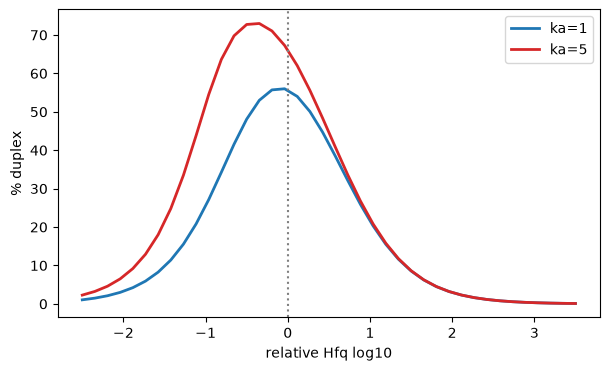

In [2]:
rel=np.logspace(-2.5,3.5,40); fig,ax=plt.subplots(figsize=(7,4))
for ka,c in [(1.0,'C0'),(5.0,'C3')]:
    y=[pct_duplex(r*10, ka=ka) for r in rel]; ax.plot(np.log10(rel),y,color=c,lw=2,label=f'ka={ka:.0f}')
    ipk=int(np.argmax(y)); print(f'ka={ka}: peak at relHfq={rel[ipk]:.2f}, peak={y[ipk]:.1f}%')
ax.axvline(0,ls=':',c='gray'); ax.set_xlabel('relative Hfq log10'); ax.set_ylabel('% duplex'); ax.legend(); plt.show()

**答**: `ka` を上げる（Hfq に乗りやすく）と、低 Hfq 側でより早く duplex が立ち上がるので **set-point（ピーク）が低 Hfq 側へ動く**。ただし random-order のままなので高 Hfq での抑制（右肩下がり）は残る。会合を強めても「隔離」の性質は消えない。

## Q2. compulsory を「mRNA が必ず先」にしても単調飽和か

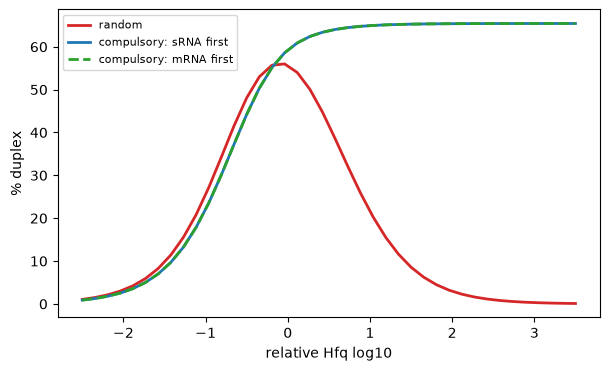

In [3]:
fig,ax=plt.subplots(figsize=(7,4))
y_r=[pct_duplex(r*10) for r in rel]
y_s=[pct_duplex(r*10, m_binds=False, mH_tern=False) for r in rel]  # sRNA first
y_m=[pct_duplex(r*10, s_binds=False, sH_tern=False) for r in rel]  # mRNA first
ax.plot(np.log10(rel),y_r,'C3',lw=2,label='random')
ax.plot(np.log10(rel),y_s,'C0',lw=2,label='compulsory: sRNA first')
ax.plot(np.log10(rel),y_m,'C2',lw=2,ls='--',label='compulsory: mRNA first')
ax.set_xlabel('relative Hfq log10'); ax.set_ylabel('% duplex'); ax.legend(fontsize=8); plt.show()

**答**: 「mRNA が必ず先」の compulsory も、「sRNA が先」と同様に**単調飽和**（高 Hfq で抑制されない）。行き止まりの singly-bound 複合体（片方だけが Hfq に乗って相手を待てない状態）が存在しないことが本質で、どちらの RNA を先に固定しても抑制は消える。抑制は **random-order 特有**、を再確認。

## Q3. もう一つの **mRNA set-point**（mH が行き止まりの場合）

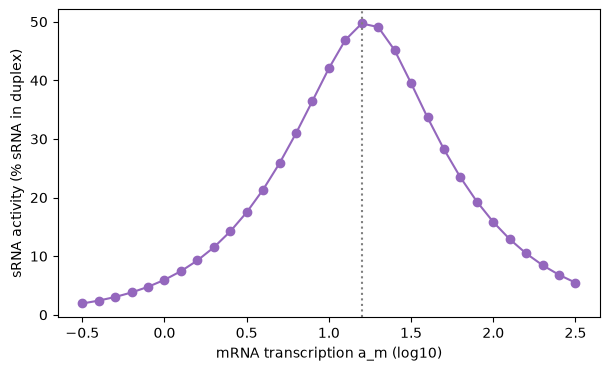

mRNA set-point: peak sRNA activity at a_m=15.8


In [4]:
# mH は三者に進めない(dead-end)。Hfq 固定、mRNA 転写 a_m を掃引し sRNA 活性を測る
def sRNA_activity(a_m, h_tot=10.0):
    v=steady(h_tot, mH_tern=False, a_m=a_m); ts=v['s']+v['sH']+v['T']+v['D']
    return 100*v['D']/ts if ts>0 else 0.0
am_grid=np.logspace(-0.5,2.5,31); act=[sRNA_activity(a) for a in am_grid]
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(np.log10(am_grid), act,'o-',color='C4')
ipk=int(np.argmax(act)); ax.axvline(np.log10(am_grid[ipk]),ls=':',c='gray')
ax.set_xlabel('mRNA transcription a_m (log10)'); ax.set_ylabel('sRNA activity (% sRNA in duplex)'); plt.show()
print(f'mRNA set-point: peak sRNA activity at a_m={am_grid[ipk]:.1f}')

**答**: mH が三者に進めない「行き止まり」だと、**mRNA を増やしすぎると Hfq が $mH$ に隔離**され、sRNA が Hfq に乗れず活性が落ちる。結果、sRNA 活性は中間の mRNA 量で最大＝**mRNA set-point**（論文の第2の set-point）。少なすぎ（標的不足）でも多すぎ（Hfq 隔離）でもダメ、という Hfq set-point の mRNA 版。

## Q4.（考察）bio-a: 結合機構が compulsory/random 寄りかの系統差

**答（考察）**: 高 Hfq への頑健性は「行き止まり singly-bound がどれだけ生じるか」で決まり、それは distal/proximal 面の使い分けと rim/テールの交換能に依存する。オーソログで **mRNA も sRNA も両面に載れる（random 寄り）**なら set-point 型（高 Hfq に弱い）、**順序が決まっている（compulsory 寄り）**なら高 Hfq に強い、と予測できる。結合機構の進化を「高 Hfq 頑健性」の差として bio-e で検討する。